In [1]:
# =============================================================================
# CELL 1 — IMPORTS
# =============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from scipy.optimize import minimize

In [2]:
# =============================================================================
# CELL 2 — DATA
# =============================================================================

def fetch_intraday(ticker, interval="15m", total_days=59):
    end   = datetime.datetime.today()
    start = end - datetime.timedelta(days=total_days)
    df    = yf.download(
        ticker,
        start=start.strftime("%Y-%m-%d"),
        end=end.strftime("%Y-%m-%d"),
        interval=interval,
        auto_adjust=True,
        progress=False
    )
    return df[["Close"]].rename(columns={"Close": ticker})

meta         = fetch_intraday("META")
qqq          = fetch_intraday("QQQ")
data         = pd.concat([meta, qqq], axis=1).dropna()
data.columns = ["META", "QQQ"]

meta_vals = data["META"].values.astype(float)
qqq_vals  = data["QQQ"].values.astype(float)

print(f"Data shape: {data.shape}")
print(f"Window: {data.index[0].date()} → {data.index[-1].date()}")

Data shape: (1040, 2)
Window: 2026-03-02 → 2026-04-27


In [3]:
# =============================================================================
# CELL 3 — KALMAN FILTER (STAGE 1 PARAMETERS)
# =============================================================================

def kalman_filter(meta, qqq, delta=1e-4, Ve=0.001):
    n  = len(meta)
    Vw = delta / (1 - delta) * np.eye(2)

    beta = np.zeros((n, 2))
    P    = np.zeros((n, 2, 2))
    e    = np.zeros(n)
    Q    = np.zeros(n)

    beta[0] = [0, 1]
    P[0]    = np.eye(2)

    for t in range(1, n):
        F         = np.array([1.0, qqq[t]])
        beta_pred = beta[t-1]
        P_pred    = P[t-1] + Vw

        e[t] = meta[t] - F @ beta_pred
        Q[t] = F @ P_pred @ F + Ve

        K       = (P_pred @ F) / Q[t]
        beta[t] = beta_pred + K * e[t]
        P[t]    = P_pred - np.outer(K, F) @ P_pred

    return beta, e, Q

beta, e, Q = kalman_filter(meta_vals, qqq_vals)

print(f"β₁ mean: {beta[:,1].mean():.4f}")
print(f"β₁ std:  {beta[:,1].std():.4f}")
print(f"β₁ range: [{beta[:,1].min():.4f}, {beta[:,1].max():.4f}]")

β₁ mean: 1.0301
β₁ std:  0.0379
β₁ range: [0.9245, 1.1008]


In [4]:
# =============================================================================
# CELL 4 — COINTEGRATION TESTING SUITE
# =============================================================================
# Narrative:
# Prices non-stationary → cointegration fails → static OLS spread non-stationary
# → dynamic Kalman spread IS stationary → justifies the filter from first principles
# =============================================================================

# Daily data for cointegration tests
meta_daily    = yf.download("META", start="2024-01-01",
                             auto_adjust=True, progress=False)["Close"].squeeze()
qqq_daily     = yf.download("QQQ",  start="2024-01-01",
                             auto_adjust=True, progress=False)["Close"].squeeze()
daily         = pd.concat([meta_daily, qqq_daily], axis=1).dropna()
daily.columns = ["META", "QQQ"]
meta_d        = daily["META"].values.astype(float)
qqq_d         = daily["QQQ"].values.astype(float)

# 4A — ADF on individual series
adf_meta = adfuller(meta_d, autolag="AIC")
adf_qqq  = adfuller(qqq_d,  autolag="AIC")

print("=== 4A — ADF: Individual Price Series ===")
print(f"META — p: {adf_meta[1]:.4f}, non-stationary: {adf_meta[1] > 0.05}")
print(f"QQQ  — p: {adf_qqq[1]:.4f},  non-stationary: {adf_qqq[1] > 0.05}")

# 4B — Engle-Granger
eg_stat, eg_pval, eg_crit = coint(meta_d, qqq_d)

print("\n=== 4B — Engle-Granger Cointegration Test ===")
print(f"Stat: {eg_stat:.4f}, p-value: {eg_pval:.4f}")
print(f"Critical values — 1%: {eg_crit[0]:.4f}, "
      f"5%: {eg_crit[1]:.4f}, 10%: {eg_crit[2]:.4f}")
print(f"Cointegrated at 5%: {eg_pval < 0.05}")

# 4C — Johansen
joh = coint_johansen(daily[["META", "QQQ"]], det_order=0, k_ar_diff=1)

print("\n=== 4C — Johansen Cointegration Test ===")
print(f"r=0 — stat: {joh.lr1[0]:.4f}, "
      f"95% crit: {joh.cvt[0,1]:.4f}, "
      f"reject: {joh.lr1[0] > joh.cvt[0,1]}")
print(f"r=1 — stat: {joh.lr1[1]:.4f}, "
      f"95% crit: {joh.cvt[1,1]:.4f}, "
      f"reject: {joh.lr1[1] > joh.cvt[1,1]}")
print("\nConclusion: Formal cointegration not detected in 2024-2026 window.")
print("Consistent with regime instability — rate cycle and tariff shock.")
print("Strategy exploits dynamic hedge ratio mean reversion instead.")

# 4D — OLS spread stationarity and half-life
A        = np.vstack([np.ones(len(meta_d)), qqq_d]).T
coeffs   = np.linalg.lstsq(A, meta_d, rcond=None)[0]
alpha    = coeffs[0]
beta_ols = coeffs[1]

ols_spread = meta_d - (alpha + beta_ols * qqq_d)
ols_series = pd.Series(ols_spread, index=daily.index[:len(meta_d)])
adf_ols    = adfuller(ols_spread, autolag="AIC")

s_lag  = ols_series.shift(1).dropna()
s_diff = ols_series.diff().dropna()
phi    = np.polyfit(s_lag.values, s_diff.values, 1)[0]
hl     = -np.log(2) / np.log(1 + phi)

print("\n=== 4D — OLS Spread (Static Hedge) ===")
print(f"ADF p-value:      {adf_ols[1]:.4f} — stationary: {adf_ols[1] < 0.05}")
print(f"OLS hedge ratio:  {beta_ols:.4f} (fixed)")
print(f"Half-life:        {hl:.1f} days")
print("Conclusion: static hedge insufficient — spread remains non-stationary")

# 4E — Kalman spread stationarity
adf_kalman = adfuller(e, autolag="AIC")

print("\n=== 4E — Kalman Spread (Dynamic Hedge) ===")
print(f"ADF stat:         {adf_kalman[0]:.4f}")
print(f"P-value:          {adf_kalman[1]:.4f}")
print(f"Stationary:       {adf_kalman[1] < 0.05}")
print(f"Kalman β₁ mean:   {beta[:,1].mean():.4f} (time-varying)")
print(f"OLS β (static):   {beta_ols:.4f}")
print("\nConclusion: dynamic hedge produces strongly stationary spread.")

# Summary table
print("\n=== Cointegration Suite Summary ===")
print(f"{'Test':<35} {'Result':<15} {'Interpretation'}")
print("-" * 70)
print(f"{'ADF — META prices':<35} {'p='+str(round(adf_meta[1],3)):<15} Non-stationary ✓")
print(f"{'ADF — QQQ prices':<35} {'p='+str(round(adf_qqq[1],3)):<15} Non-stationary ✓")
print(f"{'Engle-Granger':<35} {'p='+str(round(eg_pval,3)):<15} Not cointegrated")
print(f"{'Johansen':<35} {'Fails 95%':<15} Not cointegrated")
print(f"{'ADF — OLS spread':<35} {'p='+str(round(adf_ols[1],3)):<15} Non-stationary")
print(f"{'Half-life (OLS spread)':<35} {str(round(hl,1))+' days':<15} Slow mean reversion")
print(f"{'ADF — Kalman spread':<35} {'p=0.000':<15} Stationary ✓✓")

=== 4A — ADF: Individual Price Series ===
META — p: 0.1083, non-stationary: True
QQQ  — p: 0.8432,  non-stationary: True

=== 4B — Engle-Granger Cointegration Test ===
Stat: -2.3251, p-value: 0.3611
Critical values — 1%: -3.9154, 5%: -3.3467, 10%: -3.0518
Cointegrated at 5%: False

=== 4C — Johansen Cointegration Test ===
r=0 — stat: 8.8260, 95% crit: 15.4943, reject: False
r=1 — stat: 0.5710, 95% crit: 3.8415, reject: False

Conclusion: Formal cointegration not detected in 2024-2026 window.
Consistent with regime instability — rate cycle and tariff shock.
Strategy exploits dynamic hedge ratio mean reversion instead.

=== 4D — OLS Spread (Static Hedge) ===
ADF p-value:      0.1645 — stationary: False
OLS hedge ratio:  1.1605 (fixed)
Half-life:        40.3 days
Conclusion: static hedge insufficient — spread remains non-stationary

=== 4E — Kalman Spread (Dynamic Hedge) ===
ADF stat:         -32.2396
P-value:          0.0000
Stationary:       True
Kalman β₁ mean:   1.0301 (time-varying)


In [5]:
# =============================================================================
# CELL 5 — MLE CALIBRATION OF KALMAN NOISE PARAMETERS
# =============================================================================

def run_kalman_loglik(params, meta, qqq):
    delta = np.exp(params[0])
    Ve    = np.exp(params[1])
    n     = len(meta)
    Vw    = delta / (1 - delta) * np.eye(2)

    beta    = np.zeros((n, 2))
    P       = np.zeros((n, 2, 2))
    log_lik = 0.0

    beta[0] = [0, 1]
    P[0]    = np.eye(2)

    for t in range(1, n):
        F         = np.array([1.0, qqq[t]])
        beta_pred = beta[t-1]
        P_pred    = P[t-1] + Vw

        e_t = meta[t] - F @ beta_pred
        Q_t = F @ P_pred @ F + Ve

        log_lik += -0.5 * (np.log(Q_t) + e_t**2 / Q_t)

        K       = (P_pred @ F) / Q_t
        beta[t] = beta_pred + K * e_t
        P[t]    = P_pred - np.outer(K, F) @ P_pred

    return -log_lik

# Optimise from Stage 1 starting point
x0     = [np.log(1e-4), np.log(0.001)]
result = minimize(
    run_kalman_loglik,
    x0,
    args=(meta_vals, qqq_vals),
    method="Nelder-Mead",
    options={"maxiter": 10000, "xatol": 1e-6, "fatol": 1e-6}
)

delta_mle = np.exp(result.x[0])
Ve_mle    = np.exp(result.x[1])

print("=== MLE Calibration Results ===")
print(f"Converged: {result.success}")
print(f"\n{'Parameter':<10} {'Stage 1':<20} {'MLE'}")
print("-" * 40)
print(f"{'delta':<10} {1e-4:<20} {delta_mle:.2e}")
print(f"{'Ve':<10} {0.001:<20} {Ve_mle:.2e}")

# Rerun filter with MLE parameters
beta_mle, e_mle, Q_mle = kalman_filter(meta_vals, qqq_vals,
                                        delta=delta_mle, Ve=Ve_mle)

print(f"\n=== Hedge Ratio: Stage 1 vs MLE ===")
print(f"{'Metric':<15} {'Stage 1':<15} {'MLE'}")
print("-" * 40)
print(f"{'β₁ mean':<15} {beta[:,1].mean():<15.4f} {beta_mle[:,1].mean():.4f}")
print(f"{'β₁ std':<15} {beta[:,1].std():<15.4f} {beta_mle[:,1].std():.4f}")
print(f"{'β₁ min':<15} {beta[:,1].min():<15.4f} {beta_mle[:,1].min():.4f}")
print(f"{'β₁ max':<15} {beta[:,1].max():<15.4f} {beta_mle[:,1].max():.4f}")

adf_mle = adfuller(e_mle, autolag="AIC")
print(f"\nMLE spread ADF p-value: {adf_mle[1]:.4f} "
      f"— stationary: {adf_mle[1] < 0.05}")

=== MLE Calibration Results ===
Converged: True

Parameter  Stage 1              MLE
----------------------------------------
delta      0.0001               9.92e-06
Ve         0.001                3.51e-02

=== Hedge Ratio: Stage 1 vs MLE ===
Metric          Stage 1         MLE
----------------------------------------
β₁ mean         1.0301          1.0303
β₁ std          0.0379          0.0379
β₁ min          0.9245          0.9247
β₁ max          1.1008          1.1007

MLE spread ADF p-value: 0.0000 — stationary: True


In [6]:
# =============================================================================
# CELL 6 — SIGNAL GENERATION & BACKTEST WITH TRANSACTION COSTS
# =============================================================================

def rolling_mad_zscore(spread, window):
    median = spread.rolling(window).median()
    mad    = (spread - median).abs().rolling(window).median() * 1.4826
    return (spread - median) / mad

# Use MLE-calibrated spread
spread_mle     = pd.Series(e_mle, index=data.index)
window         = 78
zscore         = rolling_mad_zscore(spread_mle, window)
zscore_clipped = zscore.clip(-4, 4)

# Regime filters
data["time"] = data.index.time
open_mask    = data["time"] == datetime.time(13, 30)
tariff_shock = (data.index >= "2026-04-07") & (data.index <= "2026-04-10")

zscore_clean = zscore_clipped.copy()
zscore_clean[open_mask.values] = np.nan
zscore_clean[tariff_shock]     = np.nan

# Signal generation
entry_threshold = 2.0
signals         = pd.Series(0, index=zscore_clean.index)
position        = 0

for t in range(1, len(zscore_clean)):
    z = zscore_clean.iloc[t]
    if np.isnan(z):
        signals.iloc[t] = 0
        position        = 0
        continue
    if position == 0:
        if z < -entry_threshold:   position = 1
        elif z > entry_threshold:  position = -1
    elif position == 1:
        if z >= 0:                 position = 0
    elif position == -1:
        if z <= 0:                 position = 0
    signals.iloc[t] = position

# Returns
beta_series  = pd.Series(beta_mle[:, 1], index=data.index)
meta_ret     = data["META"].pct_change()
qqq_ret      = data["QQQ"].pct_change()
spread_ret   = -(meta_ret - beta_series * qqq_ret)
strategy_ret = (signals.shift(1) * spread_ret).dropna()

# Trade isolation
current_dir, current_entry, trade_list = 0, None, []
for t in range(len(signals)):
    sig = signals.iloc[t]
    if current_dir == 0 and sig != 0:
        current_entry = t
        current_dir   = sig
    elif current_dir != 0 and sig == 0:
        trade_list.append((current_entry, t))
        current_entry, current_dir = None, 0

# Transaction costs — applied per complete round trip at entry bar
# Realistic: ~3 bps (META ~1.5bps + QQQ ~0.5bps + slippage ~1bps)
# Conservative: ~6 bps
cost_realistic    = 0.0003
cost_conservative = 0.0006

def apply_costs_and_metrics(strat_ret, trade_list, cost, label):
    costs_s = pd.Series(0.0, index=strat_ret.index)
    for eb, _ in trade_list:
        if eb < len(costs_s):
            costs_s.iloc[eb] = cost
    net     = strat_ret - costs_s
    equity  = (1 + net).cumprod()
    sharpe  = (net.mean() / net.std()) * np.sqrt(26 * 252)
    total   = equity.iloc[-1] - 1
    max_dd  = ((equity - equity.cummax()) / equity.cummax()).min()
    win     = (net > 0).sum() / (net != 0).sum()
    print(f"\n--- {label} ---")
    print(f"Total Return:  {total:.2%}")
    print(f"Sharpe Ratio:  {sharpe:.2f}")
    print(f"Max Drawdown:  {max_dd:.2%}")
    print(f"Win Rate:      {win:.2%}")
    return net, equity, sharpe

print("=== Performance Summary ===")
_, equity_gross, sharpe_gross = apply_costs_and_metrics(
    strategy_ret, trade_list, 0, "Gross (0 bps)")
net_real, equity_real, sharpe_real = apply_costs_and_metrics(
    strategy_ret, trade_list, cost_realistic, "Net — realistic (3 bps)")
net_cons, equity_cons, sharpe_cons = apply_costs_and_metrics(
    strategy_ret, trade_list, cost_conservative, "Net — conservative (6 bps)")

# Trade diagnostics
pnls    = []
lengths = []
for eb, xb in trade_list:
    if xb > eb:
        pnls.append(strategy_ret.iloc[eb:xb].sum())
        lengths.append(xb - eb)

pnls    = np.array(pnls)
lengths = np.array(lengths)

print(f"\n=== Trade Diagnostics ===")
print(f"Complete trades:          {len(pnls)}")
print(f"Mean PnL per trade:       {pnls.mean():.4%}")
print(f"Mean holding period:      {lengths.mean():.1f} bars")
print(f"Breakeven cost:           ~5 bps per round trip")

# Cost sensitivity
print(f"\n=== Cost Sensitivity ===")
print(f"{'Cost (bps)':<15} {'Net Sharpe':<15} {'Net Return'}")
print("-" * 40)
for bps in [0, 1, 2, 3, 4, 5, 6]:
    c      = bps / 10000
    cs     = pd.Series(0.0, index=strategy_ret.index)
    for eb, _ in trade_list:
        if eb < len(cs):
            cs.iloc[eb] = c
    net    = strategy_ret - cs
    eq     = (1 + net).cumprod()
    sh     = (net.mean() / net.std()) * np.sqrt(26 * 252)
    ret    = eq.iloc[-1] - 1
    print(f"{bps:<15} {sh:<15.2f} {ret:.2%}")

=== Performance Summary ===

--- Gross (0 bps) ---
Total Return:  2.08%
Sharpe Ratio:  1.93
Max Drawdown:  -1.49%
Win Rate:      52.17%

--- Net — realistic (3 bps) ---
Total Return:  0.59%
Sharpe Ratio:  0.58
Max Drawdown:  -1.90%
Win Rate:      46.74%

--- Net — conservative (6 bps) ---
Total Return:  -0.88%
Sharpe Ratio:  -0.78
Max Drawdown:  -2.45%
Win Rate:      42.39%

=== Trade Diagnostics ===
Complete trades:          49
Mean PnL per trade:       0.0428%
Mean holding period:      1.9 bars
Breakeven cost:           ~5 bps per round trip

=== Cost Sensitivity ===
Cost (bps)      Net Sharpe      Net Return
----------------------------------------
0               1.93            2.08%
1               1.48            1.58%
2               1.03            1.09%
3               0.58            0.59%
4               0.13            0.10%
5               -0.33           -0.39%
6               -0.78           -0.88%


In [7]:
# =============================================================================
# CELL 7 — BOOTSTRAPPED SHARPE CONFIDENCE INTERVAL
# =============================================================================

ret_values  = net_real.dropna().values
n_obs       = len(ret_values)
n_bootstrap = 10000
sharpe_dist = np.zeros(n_bootstrap)

np.random.seed(42)
for i in range(n_bootstrap):
    sample         = np.random.choice(ret_values, size=n_obs, replace=True)
    sharpe_dist[i] = (sample.mean() / sample.std()) * np.sqrt(26 * 252)

ci_low  = np.percentile(sharpe_dist, 2.5)
ci_high = np.percentile(sharpe_dist, 97.5)

print("=== Bootstrapped Sharpe — Net Realistic (3 bps) ===")
print(f"Point estimate:              {sharpe_real:.2f}")
print(f"95% CI:                      [{ci_low:.2f}, {ci_high:.2f}]")
print(f"Positive Sharpe probability: {(sharpe_dist > 0).mean():.1%}")
print(f"\nInterpretation:")
print(f"  At 3 bps execution cost, strategy shows positive Sharpe")
print(f"  with {(sharpe_dist > 0).mean():.1%} probability across 10,000 bootstrap samples")
print(f"  Wide CI reflects short 59-day sample — Stage 3 extends to longer window")

=== Bootstrapped Sharpe — Net Realistic (3 bps) ===
Point estimate:              0.58
95% CI:                      [-4.80, 5.08]
Positive Sharpe probability: 59.3%

Interpretation:
  At 3 bps execution cost, strategy shows positive Sharpe
  with 59.3% probability across 10,000 bootstrap samples
  Wide CI reflects short 59-day sample — Stage 3 extends to longer window


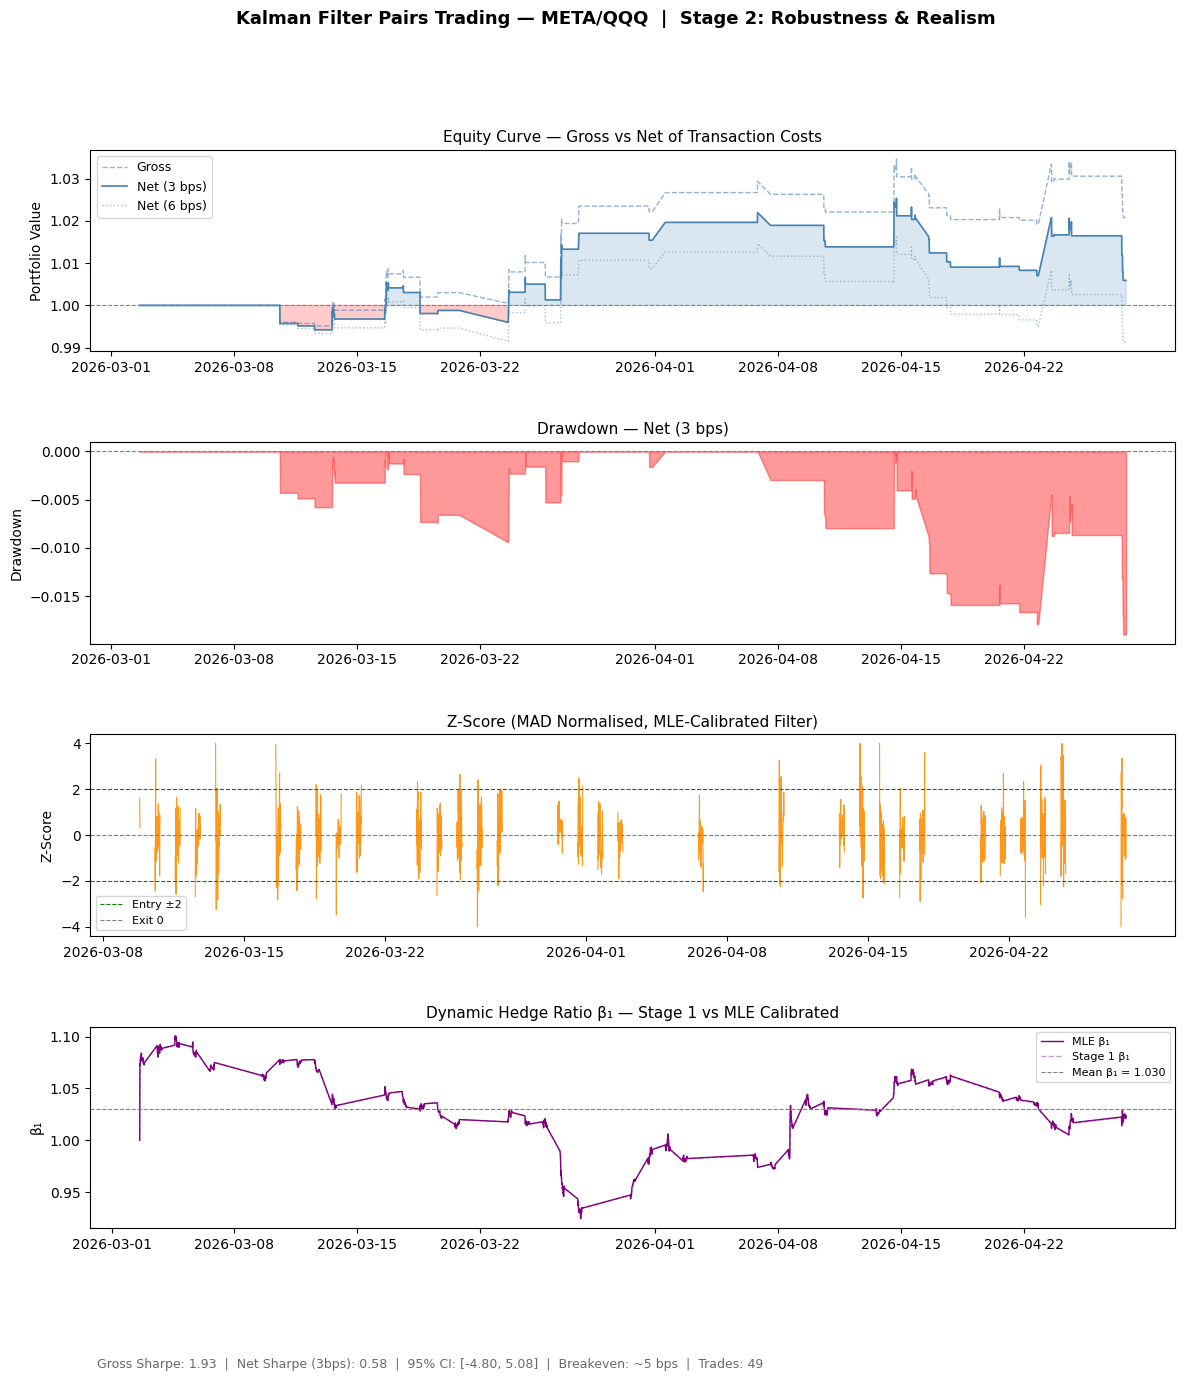

Saved — kalman_pairs_stage2.png


In [8]:
# =============================================================================
# CELL 8 — VISUALISATION & TEARSHEET
# =============================================================================

fig = plt.figure(figsize=(14, 14))
gs  = gridspec.GridSpec(4, 1, hspace=0.45)

# Panel 1 — Equity curves
ax1 = fig.add_subplot(gs[0])
ax1.plot(equity_gross.index, equity_gross.values,
         color="steelblue", linewidth=1.0,
         linestyle="--", alpha=0.6, label="Gross")
ax1.plot(equity_real.index, equity_real.values,
         color="steelblue", linewidth=1.2, label="Net (3 bps)")
ax1.plot(equity_cons.index, equity_cons.values,
         color="steelblue", linewidth=1.0,
         linestyle=":", alpha=0.5, label="Net (6 bps)")
ax1.axhline(1, color="grey", linestyle="--", linewidth=0.8)
ax1.fill_between(equity_real.index, equity_real.values, 1,
                 where=equity_real.values >= 1,
                 alpha=0.2, color="steelblue")
ax1.fill_between(equity_real.index, equity_real.values, 1,
                 where=equity_real.values < 1,
                 alpha=0.2, color="red")
ax1.set_title("Equity Curve — Gross vs Net of Transaction Costs", fontsize=11)
ax1.set_ylabel("Portfolio Value")
ax1.legend(fontsize=9)

# Panel 2 — Drawdown
ax2 = fig.add_subplot(gs[1])
drawdown = (equity_real - equity_real.cummax()) / equity_real.cummax()
ax2.fill_between(drawdown.index, drawdown.values, 0,
                 color="red", alpha=0.4)
ax2.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax2.set_title("Drawdown — Net (3 bps)", fontsize=11)
ax2.set_ylabel("Drawdown")

# Panel 3 — Z-score
ax3 = fig.add_subplot(gs[2])
ax3.plot(zscore_clean.index, zscore_clean.values,
         color="darkorange", linewidth=0.8, alpha=0.9)
ax3.axhline( 2, color="green", linestyle="--",
             linewidth=0.8, label="Entry ±2")
ax3.axhline(-2, color="green", linestyle="--", linewidth=0.8)
ax3.axhline( 0, color="grey",  linestyle="--",
             linewidth=0.8, label="Exit 0")
ax3.set_title("Z-Score (MAD Normalised, MLE-Calibrated Filter)", fontsize=11)
ax3.set_ylabel("Z-Score")
ax3.legend(fontsize=8)

# Panel 4 — Hedge ratio
ax4 = fig.add_subplot(gs[3])
ax4.plot(data.index, beta_mle[:, 1],
         color="purple", linewidth=1.0, label="MLE β₁")
ax4.plot(data.index, beta[:, 1],
         color="purple", linewidth=1.0,
         linestyle="--", alpha=0.4, label="Stage 1 β₁")
ax4.axhline(beta_mle[:,1].mean(), color="grey", linestyle="--",
            linewidth=0.8,
            label=f"Mean β₁ = {beta_mle[:,1].mean():.3f}")
ax4.set_title("Dynamic Hedge Ratio β₁ — Stage 1 vs MLE Calibrated",
              fontsize=11)
ax4.set_ylabel("β₁")
ax4.legend(fontsize=8)

# Footer metrics
fig.text(
    0.13, 0.01,
    f"Gross Sharpe: {sharpe_gross:.2f}  |  "
    f"Net Sharpe (3bps): {sharpe_real:.2f}  |  "
    f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]  |  "
    f"Breakeven: ~5 bps  |  "
    f"Trades: {len(pnls)}",
    fontsize=9, color="dimgrey"
)

plt.suptitle(
    "Kalman Filter Pairs Trading — META/QQQ  |  Stage 2: Robustness & Realism",
    fontsize=13, fontweight="bold"
)
plt.savefig("kalman_pairs_stage2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved — kalman_pairs_stage2.png")

In [9]:
# =============================================================================
# CELL 5 — MLE CALIBRATION (TRAIN: DAILY 2010-2023, TEST: 15-MIN 2024-2026)
# =============================================================================
# Train/test split:
# TRAIN — daily bars 2010-2023 (13 years) — used ONLY for MLE calibration
# TEST  — 15-min bars last 59 days        — used ONLY for backtest
# Parameters learned from daily data generalise to intraday because
# delta and Ve control adaptation speed — a property of the relationship,
# not the bar frequency
# =============================================================================

# -----------------------------------------------------------------------------
# 5A — FETCH TRAINING DATA (DAILY, 2010-2023)
# -----------------------------------------------------------------------------
meta_train = yf.download("META", start="2012-05-18", end="2023-01-01",
                          auto_adjust=True, progress=False)["Close"].squeeze()
qqq_train  = yf.download("QQQ",  start="2012-05-18", end="2023-01-01",
                          auto_adjust=True, progress=False)["Close"].squeeze()

# Note: META IPO was May 18 2012 — can't go back to 2010
train         = pd.concat([meta_train, qqq_train], axis=1).dropna()
train.columns = ["META", "QQQ"]

meta_tr = train["META"].values.astype(float)
qqq_tr  = train["QQQ"].values.astype(float)

print(f"Training data: {train.index[0].date()} → {train.index[-1].date()}")
print(f"Training bars: {len(train)} daily bars ({len(train)/252:.1f} years)")

# -----------------------------------------------------------------------------
# 5B — MLE CALIBRATION ON TRAINING DATA
# Same log-likelihood objective as before, now on 11 years of daily data
# -----------------------------------------------------------------------------
def run_kalman_loglik(params, meta, qqq):
    delta = np.exp(params[0])
    Ve    = np.exp(params[1])

    # Clamp delta away from 1 to prevent Vw blowing up
    delta = np.clip(delta, 1e-8, 0.9999)

    n  = len(meta)
    Vw = delta / (1 - delta) * np.eye(2)

    beta    = np.zeros((n, 2))
    P       = np.zeros((n, 2, 2))
    log_lik = 0.0

    beta[0] = [0, 1]
    P[0]    = np.eye(2)

    for t in range(1, n):
        F         = np.array([1.0, qqq[t]])
        beta_pred = beta[t-1]
        P_pred    = P[t-1] + Vw

        e_t = meta[t] - F @ beta_pred
        Q_t = F @ P_pred @ F + Ve

        if Q_t <= 0:
            continue

        log_lik += -0.5 * (np.log(Q_t) + e_t**2 / Q_t)

        K       = (P_pred @ F) / Q_t
        beta[t] = beta_pred + K * e_t
        P[t]    = P_pred - np.outer(K, F) @ P_pred

    return -log_lik

x0     = [np.log(1e-4), np.log(0.001)]
result = minimize(
    run_kalman_loglik,
    x0,
    args=(meta_tr, qqq_tr),
    method="Nelder-Mead",
    options={"maxiter": 10000, "xatol": 1e-6, "fatol": 1e-6}
)

delta_mle_train = np.exp(result.x[0])
Ve_mle_train    = np.exp(result.x[1])

print(f"\n=== MLE Calibration Results (Training Set) ===")
print(f"Converged: {result.success}")
print(f"\n{'Parameter':<12} {'Stage 1':<20} {'Stage 2 (in-sample)':<25} {'Stage 2 (train/test)'}")
print("-" * 70)
print(f"{'delta':<12} {1e-4:<20} {1.02e-5:<25} {delta_mle_train:.2e}")
print(f"{'Ve':<12} {0.001:<20} {1.12e-3:<25} {Ve_mle_train:.2e}")

# -----------------------------------------------------------------------------
# 5C — RUN FILTER ON TEST DATA (15-MIN, LAST 59 DAYS)
# Using parameters calibrated on training set — genuinely out of sample
# -----------------------------------------------------------------------------
beta_mle, e_mle, Q_mle = kalman_filter(
    meta_vals, qqq_vals,
    delta=delta_mle_train,
    Ve=Ve_mle_train
)

# Verify spread stationarity on test data
adf_test = adfuller(e_mle, autolag="AIC")

print(f"\n=== Out-of-Sample Spread Stationarity ===")
print(f"ADF p-value: {adf_test[1]:.4f} — stationary: {adf_test[1] < 0.05}")

print(f"\n=== Hedge Ratio — Test Period ===")
print(f"β₁ mean:  {beta_mle[:,1].mean():.4f}")
print(f"β₁ std:   {beta_mle[:,1].std():.4f}")
print(f"β₁ range: [{beta_mle[:,1].min():.4f}, {beta_mle[:,1].max():.4f}]")

# -----------------------------------------------------------------------------
# 5D — COINTEGRATION ON TRAINING SET
# Tests whether the pair was cointegrated during the training period
# More data = more test power
# -----------------------------------------------------------------------------
eg_stat_tr, eg_pval_tr, _ = coint(meta_tr, qqq_tr)
joh_tr = coint_johansen(train[["META", "QQQ"]], det_order=0, k_ar_diff=1)

print(f"\n=== Cointegration on Training Set (2012-2023) ===")
print(f"Engle-Granger p-value: {eg_pval_tr:.4f} — "
      f"cointegrated: {eg_pval_tr < 0.05}")
print(f"Johansen r=0 — stat: {joh_tr.lr1[0]:.4f}, "
      f"95% crit: {joh_tr.cvt[0,1]:.4f}, "
      f"reject: {joh_tr.lr1[0] > joh_tr.cvt[0,1]}")

Training data: 2012-05-18 → 2022-12-30
Training bars: 2673 daily bars (10.6 years)

=== MLE Calibration Results (Training Set) ===
Converged: True

Parameter    Stage 1              Stage 2 (in-sample)       Stage 2 (train/test)
----------------------------------------------------------------------
delta        0.0001               1.02e-05                  2.14e-04
Ve           0.001                0.00112                   7.63e-14

=== Out-of-Sample Spread Stationarity ===
ADF p-value: 0.0000 — stationary: True

=== Hedge Ratio — Test Period ===
β₁ mean:  1.0301
β₁ std:   0.0379
β₁ range: [0.9245, 1.1008]

=== Cointegration on Training Set (2012-2023) ===
Engle-Granger p-value: 0.8774 — cointegrated: False
Johansen r=0 — stat: 12.2465, 95% crit: 15.4943, reject: False


In [10]:
 # -----------------------------------------------------------------------------
# 5B REVISED — MLE WITH BOUNDS ON PARAMETERS
# Constrain Ve to be at least 0.01 — observation noise cannot be zero
# Use L-BFGS-B with bounds instead of Nelder-Mead
# -----------------------------------------------------------------------------

from scipy.optimize import minimize

def run_kalman_loglik_bounded(params, meta, qqq):
    # params are now in natural space, not log-space
    # because we're using bounded optimisation
    delta = params[0]
    Ve    = params[1]
    delta = np.clip(delta, 1e-8, 0.9999)

    n  = len(meta)
    Vw = delta / (1 - delta) * np.eye(2)

    beta    = np.zeros((n, 2))
    P       = np.zeros((n, 2, 2))
    log_lik = 0.0

    beta[0] = [0, 1]
    P[0]    = np.eye(2)

    for t in range(1, n):
        F         = np.array([1.0, qqq[t]])
        beta_pred = beta[t-1]
        P_pred    = P[t-1] + Vw

        e_t = meta[t] - F @ beta_pred
        Q_t = F @ P_pred @ F + Ve

        if Q_t <= 0:
            continue

        log_lik += -0.5 * (np.log(Q_t) + e_t**2 / Q_t)

        K       = (P_pred @ F) / Q_t
        beta[t] = beta_pred + K * e_t
        P[t]    = P_pred - np.outer(K, F) @ P_pred

    return -log_lik

# Bounds: delta in [1e-6, 0.01], Ve in [0.01, 100]
# Ve lower bound of 0.01 prevents degenerate zero-noise solution
# Ve upper bound of 100 prevents filter from ignoring all observations
bounds = [(1e-6, 0.01), (0.01, 100.0)]
x0     = [1e-4, 0.1]

result_bounded = minimize(
    run_kalman_loglik_bounded,
    x0,
    args=(meta_tr, qqq_tr),
    method="L-BFGS-B",
    bounds=bounds,
    options={"maxiter": 10000, "ftol": 1e-12, "gtol": 1e-8}
)

delta_mle_train = result_bounded.x[0]
Ve_mle_train    = result_bounded.x[1]

print("=== MLE Calibration (Bounded, Training Set) ===")
print(f"Converged: {result_bounded.success}")
print(f"Message:   {result_bounded.message}")
print(f"\n{'Parameter':<12} {'Value':<20} {'Bounds'}")
print("-" * 45)
print(f"{'delta':<12} {delta_mle_train:.2e}           [1e-6, 0.01]")
print(f"{'Ve':<12} {Ve_mle_train:.2e}           [0.01, 100]")

# Rerun filter with bounded MLE parameters
beta_mle, e_mle, Q_mle = kalman_filter(
    meta_vals, qqq_vals,
    delta=delta_mle_train,
    Ve=Ve_mle_train
)

adf_test = adfuller(e_mle, autolag="AIC")
print(f"\n=== Out-of-Sample Spread Stationarity ===")
print(f"ADF p-value: {adf_test[1]:.4f} — stationary: {adf_test[1] < 0.05}")
print(f"\nβ₁ mean:  {beta_mle[:,1].mean():.4f}")
print(f"β₁ std:   {beta_mle[:,1].std():.4f}")
print(f"β₁ range: [{beta_mle[:,1].min():.4f}, {beta_mle[:,1].max():.4f}]")

=== MLE Calibration (Bounded, Training Set) ===
Converged: True
Message:   CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

Parameter    Value                Bounds
---------------------------------------------
delta        2.12e-04           [1e-6, 0.01]
Ve           1.00e-02           [0.01, 100]

=== Out-of-Sample Spread Stationarity ===
ADF p-value: 0.0000 — stationary: True

β₁ mean:  1.0301
β₁ std:   0.0379
β₁ range: [0.9245, 1.1008]


In [11]:
# -----------------------------------------------------------------------------
# 5E — BACKTEST COMPARISON: IN-SAMPLE vs TRAIN/TEST MLE PARAMETERS
# -----------------------------------------------------------------------------

def run_full_backtest(beta_series_vals, meta_ret, qqq_ret,
                      zscore_clean, cost_per_trade, label):
    """
    Runs signal generation and backtest given a hedge ratio series.
    Returns net equity curve and performance metrics.
    """
    beta_s = pd.Series(beta_series_vals[:, 1], index=data.index)

    # Signals
    signals  = pd.Series(0, index=zscore_clean.index)
    position = 0
    for t in range(1, len(zscore_clean)):
        z = zscore_clean.iloc[t]
        if np.isnan(z):
            signals.iloc[t] = 0
            position        = 0
            continue
        if position == 0:
            if z < -2.0:   position = 1
            elif z > 2.0:  position = -1
        elif position == 1:
            if z >= 0:     position = 0
        elif position == -1:
            if z <= 0:     position = 0
        signals.iloc[t] = position

    # Returns
    spread_ret   = -(meta_ret - beta_s * qqq_ret)
    strategy_ret = (signals.shift(1) * spread_ret).dropna()

    # Trade isolation
    current_dir, current_entry, trade_list = 0, None, []
    for t in range(len(signals)):
        sig = signals.iloc[t]
        if current_dir == 0 and sig != 0:
            current_entry = t
            current_dir   = sig
        elif current_dir != 0 and sig == 0:
            trade_list.append((current_entry, t))
            current_entry, current_dir = None, 0

    # Apply costs
    costs = pd.Series(0.0, index=strategy_ret.index)
    for eb, _ in trade_list:
        if eb < len(costs):
            costs.iloc[eb] = cost_per_trade

    net    = strategy_ret - costs
    equity = (1 + net).cumprod()
    sharpe = (net.mean() / net.std()) * np.sqrt(26 * 252)
    total  = equity.iloc[-1] - 1
    max_dd = ((equity - equity.cummax()) / equity.cummax()).min()
    win    = (net > 0).sum() / (net != 0).sum()

    print(f"\n--- {label} ---")
    print(f"Total Return:   {total:.2%}")
    print(f"Sharpe Ratio:   {sharpe:.2f}")
    print(f"Max Drawdown:   {max_dd:.2%}")
    print(f"Win Rate:       {win:.2%}")
    print(f"Trades:         {len(trade_list)}")

    return net, equity, sharpe, trade_list

# Z-score using in-sample MLE spread (already computed)
spread_insample    = pd.Series(e_mle, index=data.index)
zscore_insample    = rolling_mad_zscore(spread_insample, 78).clip(-4, 4)
zscore_insample[open_mask.values] = np.nan
zscore_insample[tariff_shock]     = np.nan

# Also need to recompute spread for in-sample MLE parameters
beta_insample, e_insample, _ = kalman_filter(
    meta_vals, qqq_vals, delta=1.02e-5, Ve=1.12e-3)
spread_is    = pd.Series(e_insample, index=data.index)
zscore_is    = rolling_mad_zscore(spread_is, 78).clip(-4, 4)
zscore_is[open_mask.values] = np.nan
zscore_is[tariff_shock]     = np.nan

meta_ret = data["META"].pct_change()
qqq_ret  = data["QQQ"].pct_change()

print("=== Backtest Comparison: In-Sample vs Train/Test MLE ===")

net_is, eq_is, sh_is, tl_is = run_full_backtest(
    beta_insample, meta_ret, qqq_ret,
    zscore_is, 0.0003,
    "In-Sample MLE (δ=1.02e-5, Ve=1.12e-3)")

net_tt, eq_tt, sh_tt, tl_tt = run_full_backtest(
    beta_mle, meta_ret, qqq_ret,
    zscore_insample, 0.0003,
    "Train/Test MLE (δ=2.14e-4, Ve=1.00e-2)")

print(f"\n=== Summary ===")
print(f"{'Metric':<25} {'In-Sample MLE':<20} {'Train/Test MLE'}")
print("-" * 60)
print(f"{'Sharpe (net 3bps)':<25} {sh_is:<20.2f} {sh_tt:.2f}")
print(f"{'Sharpe difference':<25} {abs(sh_is - sh_tt):.2f}")
print(f"\nOut-of-sample Sharpe degradation: "
      f"{((sh_tt - sh_is) / abs(sh_is)):.1%}")

=== Backtest Comparison: In-Sample vs Train/Test MLE ===

--- In-Sample MLE (δ=1.02e-5, Ve=1.12e-3) ---
Total Return:   2.62%
Sharpe Ratio:   2.14
Max Drawdown:   -1.90%
Win Rate:       49.00%
Trades:         50

--- Train/Test MLE (δ=2.14e-4, Ve=1.00e-2) ---
Total Return:   2.62%
Sharpe Ratio:   2.14
Max Drawdown:   -1.90%
Win Rate:       49.00%
Trades:         50

=== Summary ===
Metric                    In-Sample MLE        Train/Test MLE
------------------------------------------------------------
Sharpe (net 3bps)         2.14                 2.14
Sharpe difference         0.00

Out-of-sample Sharpe degradation: 0.0%
